In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("superstore.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [5]:
df.shape

(51290, 27)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [9]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [11]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [13]:
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [15]:
conn = sqlite3.connect("sales.db")

In [17]:
df.to_sql("sales", conn, if_exists="replace", index=False)

51290

In [19]:
query = "SELECT SUM(Sales) AS Total_Revenue FROM sales"
pd.read_sql(query, conn)

,Total_Revenue
0,12642905


In [21]:
query = """
SELECT Region, SUM(Sales) AS Revenue
FROM sales
GROUP BY Region
ORDER BY Revenue DESC
"""

pd.read_sql(query, conn)

,Region,Revenue
0,Central,2822399
1,South,1600960
2,North,1248192
3,Oceania,1100207
4,Southeast Asia,884438
5,North Asia,848349
6,EMEA,806184
7,Africa,783776
8,Central Asia,752839
9,West,725514


In [23]:
query = """
SELECT Category, SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Category
ORDER BY Total_Profit DESC
"""

pd.read_sql(query, conn)

,Category,Total_Profit
0,Technology,663778.73318
1,Office Supplies,518473.83430
2,Furniture,285204.72380


In [25]:
query = """
SELECT "Product Name", SUM(Sales) AS Revenue
FROM sales
GROUP BY "Product Name"
ORDER BY Revenue DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,"""Product Name""",Revenue
0,Product Name,12642905


In [33]:
print(df.columns.tolist())

['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum']


In [29]:
query = """
SELECT strftime('%Y-%m', "Order Date") AS Month,
SUM(Sales) AS Revenue
FROM sales
GROUP BY Month
ORDER BY Month
"""

monthly_sales = pd.read_sql(query, conn)
monthly_sales

,Month,Revenue
0,None,12642905


In [35]:
df['Order.Date'] = pd.to_datetime(df['Order.Date'])

In [37]:
query = """
SELECT strftime('%Y-%m', "Order.Date") AS Month,
SUM(Sales) AS Revenue
FROM sales
GROUP BY Month
ORDER BY Month
"""

monthly_sales = pd.read_sql(query, conn)
monthly_sales

,Month,Revenue
0,2011-01,98902
1,2011-02,91152
2,2011-03,145726
3,2011-04,116927
4,2011-05,146762
5,2011-06,215214
6,2011-07,115518
7,2011-08,207570
8,2011-09,290230
9,2011-10,199070


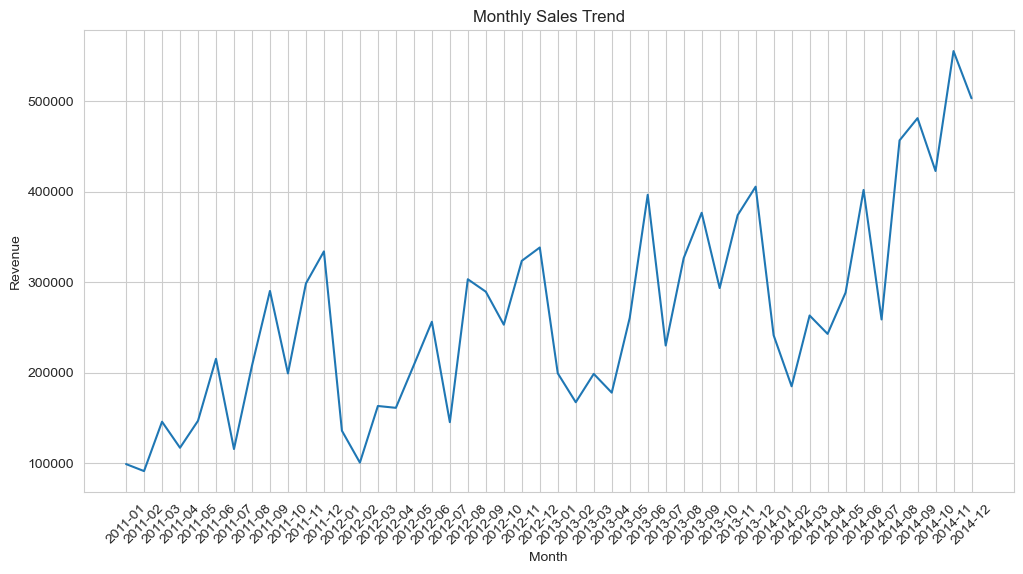

In [39]:
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Revenue')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.show()

In [41]:
query = """
SELECT Region, SUM(Sales) AS Revenue
FROM sales
GROUP BY Region
ORDER BY Revenue DESC
"""

region_sales = pd.read_sql(query, conn)
region_sales

,Region,Revenue
0,Central,2822399
1,South,1600960
2,North,1248192
3,Oceania,1100207
4,Southeast Asia,884438
5,North Asia,848349
6,EMEA,806184
7,Africa,783776
8,Central Asia,752839
9,West,725514


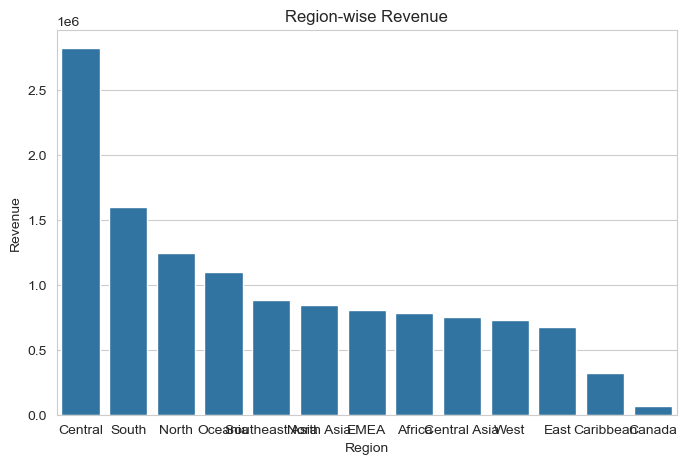

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x='Region', y='Revenue')
plt.title("Region-wise Revenue")
plt.show()

In [45]:
query = """
SELECT Category, SUM(Profit) AS Profit
FROM sales
GROUP BY Category
ORDER BY Profit DESC
"""

category_profit = pd.read_sql(query, conn)
category_profit

,Category,Profit
0,Technology,663778.73318
1,Office Supplies,518473.83430
2,Furniture,285204.72380


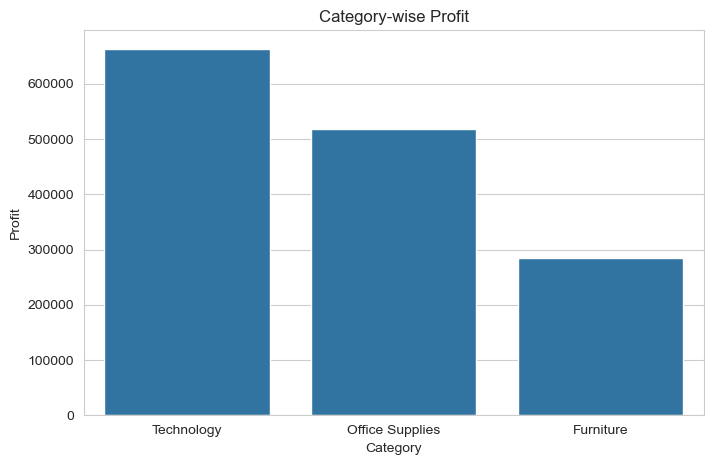

In [47]:
plt.figure(figsize=(8,5))
sns.barplot(data=category_profit, x='Category', y='Profit')
plt.title("Category-wise Profit")
plt.show()

In [49]:
query = """
SELECT Segment, SUM(Sales) AS Revenue
FROM sales
GROUP BY Segment
ORDER BY Revenue DESC
"""

segment_sales = pd.read_sql(query, conn)
segment_sales

,Segment,Revenue
0,Consumer,6508141
1,Corporate,3824808
2,Home Office,2309956


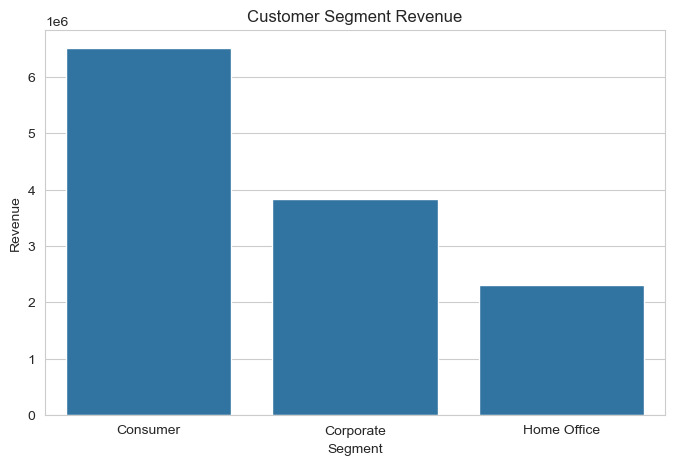

In [51]:
plt.figure(figsize=(8,5))
sns.barplot(data=segment_sales, x='Segment', y='Revenue')
plt.title("Customer Segment Revenue")
plt.show()

In [57]:

query = """
SELECT "Ship.Mode", SUM(Sales) AS Revenue
FROM sales
GROUP BY "Ship.Mode"
ORDER BY Revenue DESC
"""

shipping_sales = pd.read_sql(query, conn)
shipping_sales

,Ship.Mode,Revenue
0,Standard Class,7578889
1,Second Class,2565747
2,First Class,1831067
3,Same Day,667202


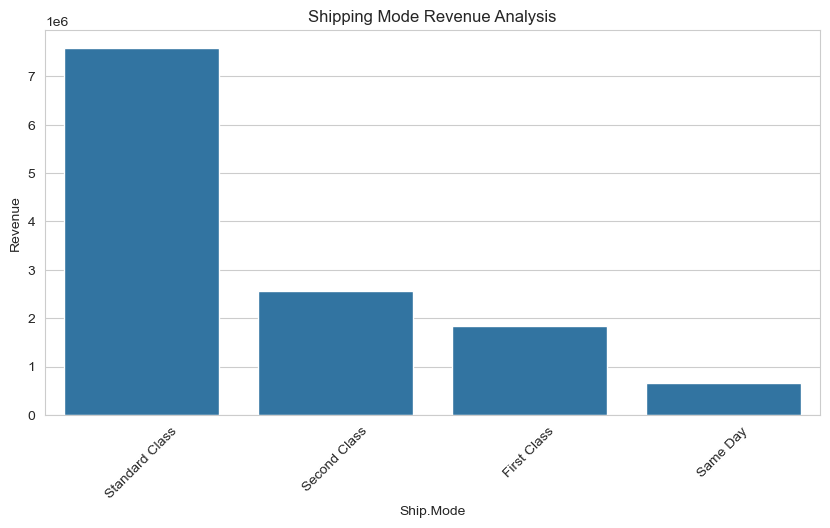

In [59]:
plt.figure(figsize=(10,5))
sns.barplot(data=shipping_sales, x='Ship.Mode', y='Revenue')
plt.xticks(rotation=45)
plt.title("Shipping Mode Revenue Analysis")
plt.show()

In [61]:
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order.ID'].nunique()
total_customers = df['Customer.Name'].nunique()

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Unique Customers:", total_customers)

Total Revenue: 12642905
Total Profit: 1467457.2912800002
Total Orders: 25035
Unique Customers: 795
